# 🚁 Contagem de Público em Imagens de Drone (YOLOv8)
Este notebook foi gerado automaticamente para rodar a aplicação completa no Google Colab.

## 1. Instalação de Dependências

In [15]:
!pip install ultralytics opencv-python-headless numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.1
[notice] To update, run: C:\Users\USUARIO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


## 2. Código da Aplicação (Módulos Integrados)

In [16]:
import cv2
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt

# --- tiling.py ---
"""
tiling.py
Responsável por fatiar o mosaico em tiles com sobreposição (overlap),
evitando perdas de detecção nas bordas.
"""



@dataclass
class Tile:
    """Representa um tile com sua imagem e offset global."""
    image: np.ndarray
    x_offset: int   # coluna (px) no mosaico original
    y_offset: int   # linha  (px) no mosaico original


def slice_mosaic(
    mosaic: np.ndarray,
    tile_size: int = 1280,
    overlap: float = 0.2
) -> List[Tile]:
    """
    Fatia o mosaico em tiles quadrados com sobreposição.

    Args:
        mosaic    : Imagem completa (H x W x 3, BGR).
        tile_size : Lado do tile em pixels.
        overlap   : Fração de sobreposição entre tiles adjacentes (0–1).

    Returns:
        Lista de objetos Tile com imagem e posição global.
    """
    h, w = mosaic.shape[:2]
    step = int(tile_size * (1 - overlap))   # passo com overlap
    tiles: List[Tile] = []

    for y in range(0, h, step):
        for x in range(0, w, step):
            # Garante que o tile não ultrapasse as bordas do mosaico
            x_end = min(x + tile_size, w)
            y_end = min(y + tile_size, h)
            x_start = max(0, x_end - tile_size)
            y_start = max(0, y_end - tile_size)

            crop = mosaic[y_start:y_end, x_start:x_end]
            tiles.append(Tile(image=crop, x_offset=x_start, y_offset=y_start))

    return tiles


# --- detector.py ---
"""
detector.py
Executa YOLOv8 sobre cada tile e mapeia as bounding boxes
para coordenadas globais do mosaico.
"""




# Classes do COCO que representam pessoas em imagens aéreas.
# Unificá-las reduz falsos negativos causados por variações de pose e altitude.
PERSON_CLASSES = {
    0: "person",       # COCO class 0
    # Se usar modelo especializado UAV, adicione IDs adicionais aqui
}


@dataclass
class Detection:
    """Detecção individual com coordenadas globais no mosaico."""
    x1: float
    y1: float
    x2: float
    y2: float
    confidence: float
    class_name: str = "person"


def run_yolo_on_tile(
    model: YOLO,
    tile: Tile,
    conf_threshold: float = 0.30,
    imgsz: int = 736,
    iou_threshold: float = 0.45,
) -> List[Detection]:
    """
    Executa inferência em um tile e converte as caixas
    para coordenadas absolutas no mosaico original.

    Args:
        model          : Instância do YOLOv8 carregada.
        tile           : Tile com imagem e offsets.
        conf_threshold : Confiança mínima para aceitar uma detecção.
                         ↓ para cenas densas / ↑ para reduzir FP em cenas esparsas.
        imgsz          : Resolução de entrada da rede.
                         Valores ≥ 736 melhoram a detecção de pessoas pequenas.
        iou_threshold  : IoU para NMS interna do YOLO.
                         ↓ (ex: 0.35) em multidões densas para separar indivíduos.

    Returns:
        Lista de Detection com coordenadas globais.
    """
    results = model.predict(
        source=tile.image,
        imgsz=imgsz,
        conf=conf_threshold,
        iou=iou_threshold,
        classes=list(PERSON_CLASSES.keys()),  # filtra apenas pessoas
        verbose=False,
        device="cuda" if _cuda_available() else "cpu",
    )

    detections: List[Detection] = []

    for result in results:
        if result.boxes is None:
            continue
        for box in result.boxes:
            # Coordenadas locais ao tile
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            conf = float(box.conf[0])
            cls_id = int(box.cls[0])

            # Somente classes mapeadas como "pessoa"
            if cls_id not in PERSON_CLASSES:
                continue

            # Converte para coordenadas globais no mosaico
            detections.append(Detection(
                x1=x1 + tile.x_offset,
                y1=y1 + tile.y_offset,
                x2=x2 + tile.x_offset,
                y2=y2 + tile.y_offset,
                confidence=conf,
            ))

    return detections


def _cuda_available() -> bool:
    import torch
    return torch.cuda.is_available()


# --- nms.py ---
"""
nms.py
Aplica Non-Maximum Suppression (NMS) global sobre todas as detecções
provenientes de múltiplos tiles para eliminar duplicatas de sobreposição.
"""


def apply_global_nms(
    detections: List[Detection],
    iou_threshold: float = 0.50,
) -> List[Detection]:
    if not detections:
        return []

    boxes = np.array([[d.x1, d.y1, d.x2, d.y2] for d in detections], dtype=np.float32)
    scores = np.array([d.confidence for d in detections], dtype=np.float32)

    # cv2.dnn.NMSBoxes espera (x, y, w, h)
    boxes_xywh = boxes.copy()
    boxes_xywh[:, 2] -= boxes_xywh[:, 0]   # w = x2 - x1
    boxes_xywh[:, 3] -= boxes_xywh[:, 1]   # h = y2 - y1

    indices = cv2.dnn.NMSBoxes(
        bboxes=boxes_xywh.tolist(),
        scores=scores.tolist(),
        score_threshold=0.0,       # filtro já foi feito na inferência
        nms_threshold=iou_threshold,
    )

    if len(indices) == 0:
        return []

    kept = [detections[i] for i in indices.flatten()]
    return kept


# --- visualizer.py ---
"""
visualizer.py
Desenha as bounding boxes sobre o mosaico e salva o resultado.
"""


def _confidence_color(conf: float) -> tuple:
    if conf >= 0.70:
        return (0, 220, 0)      # verde
    elif conf >= 0.45:
        return (0, 200, 255)    # amarelo
    else:
        return (0, 60, 255)     # vermelho

def draw_detections(
    mosaic: np.ndarray,
    detections: List[Detection],
    max_display_size: int = 4000,
) -> np.ndarray:
    annotated = mosaic.copy()

    for det in detections:
        x1, y1, x2, y2 = int(det.x1), int(det.y1), int(det.x2), int(det.y2)
        color = _confidence_color(det.confidence)
        label = f"{det.confidence:.2f}"

        # Caixa delimitadora
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, thickness=2)

        # Fundo do texto
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(annotated, (x1, y1 - th - 4), (x1 + tw, y1), color, -1)
        cv2.putText(annotated, label, (x1, y1 - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)

    # Redimensiona para visualização gerenciável
    h, w = annotated.shape[:2]
    scale = min(max_display_size / max(h, w), 1.0)
    if scale < 1.0:
        annotated = cv2.resize(annotated, (int(w * scale), int(h * scale)))

    return annotated

def export_results(
    annotated: np.ndarray,
    count: int,
    output_path: str = "output_crowd.jpg",
) -> None:
    h, w = annotated.shape[:2]
    banner = f"TOTAL DETECTADO: {count} pessoas"

    # Fundo semitransparente no topo
    overlay = annotated.copy()
    cv2.rectangle(overlay, (0, 0), (w, 50), (20, 20, 20), -1)
    cv2.addWeighted(overlay, 0.6, annotated, 0.4, 0, annotated)

    cv2.putText(annotated, banner, (15, 35),
                cv2.FONT_HERSHEY_DUPLEX, 1.1, (255, 255, 255), 2, cv2.LINE_AA)

    cv2.imwrite(output_path, annotated)
    print(f"[✓] Resultado salvo em: {output_path}")




## 3. Definir Caminho da Imagem
O caminho da imagem de teste está definido abaixo.

In [9]:
import os

image_path = r"g:\Meu Drive\AGENTES\AGENTE CONTAGEM DE PÚBLICO\.testes\nova_imagem_teste.jpg"
print(f"Imagem carregada com sucesso: {image_path}")


Imagem carregada com sucesso: g:\Meu Drive\AGENTES\AGENTE CONTAGEM DE PÚBLICO\.testes\nova_imagem_teste.jpg


## 4. Execução do Pipeline
O código abaixo executará o pipeline completo (Fatiamento, Detecção YOLO, NMS Global e Visualização).

In [17]:
# Parâmetros da aplicação
TILE_SIZE = 256
OVERLAP = 0.20
MODEL_WEIGHTS = "yolov8n.pt"
IMGSZ = 1280
CONF_THRESH = 0.30
IOU_LOCAL = 0.45
IOU_GLOBAL = 0.50
OUTPUT_PATH = "resultado_contagem.jpg"

print(f"[1/5] Carregando mosaico: {image_path}")
mosaic = cv2.imread(image_path)
if mosaic is None:
    raise FileNotFoundError("Erro ao carregar a imagem!")

print(f"      Resolução: {mosaic.shape[1]}x{mosaic.shape[0]} px")

print(f"[2/5] Fatiando em tiles {TILE_SIZE}px com {OVERLAP*100:.0f}% overlap...")
tiles = slice_mosaic(mosaic, tile_size=TILE_SIZE, overlap=OVERLAP)
print(f"      Total de tiles gerados: {len(tiles)}")

print(f"[3/5] Carregando modelo: {MODEL_WEIGHTS}")
model = YOLO(MODEL_WEIGHTS)

print(f"[4/5] Executando inferência (imgsz={IMGSZ}, conf={CONF_THRESH})...")
all_detections = []

for i, tile in enumerate(tiles, 1):
    dets = run_yolo_on_tile(
        model=model,
        tile=tile,
        conf_threshold=CONF_THRESH,
        imgsz=IMGSZ,
        iou_threshold=IOU_LOCAL,
    )
    all_detections.extend(dets)
    
print(f"\n      Sub-total pré-NMS global: {len(all_detections)} caixas")

# 5. NMS global
final_detections = apply_global_nms(all_detections, iou_threshold=IOU_GLOBAL)
count = len(final_detections)
print(f"\n[5/5] ✅ Contagem final: {count} pessoas detectadas")

# 6. Exporta e Visualiza
annotated = draw_detections(mosaic, final_detections)
export_results(annotated, count, output_path=OUTPUT_PATH)

print(f"Salvou o resultado em {OUTPUT_PATH}")

[1/5] Carregando mosaico: g:\Meu Drive\AGENTES\AGENTE CONTAGEM DE PÚBLICO\.testes\nova_imagem_teste.jpg
      Resolução: 1024x682 px
[2/5] Fatiando em tiles 256px com 20% overlap...
      Total de tiles gerados: 24
[3/5] Carregando modelo: yolov8n.pt
[4/5] Executando inferência (imgsz=1280, conf=0.3)...

      Sub-total pré-NMS global: 258 caixas

[5/5] ✅ Contagem final: 173 pessoas detectadas
[✓] Resultado salvo em: resultado_contagem.jpg
Salvou o resultado em resultado_contagem.jpg


## 5. Visualizar o Resultado Final

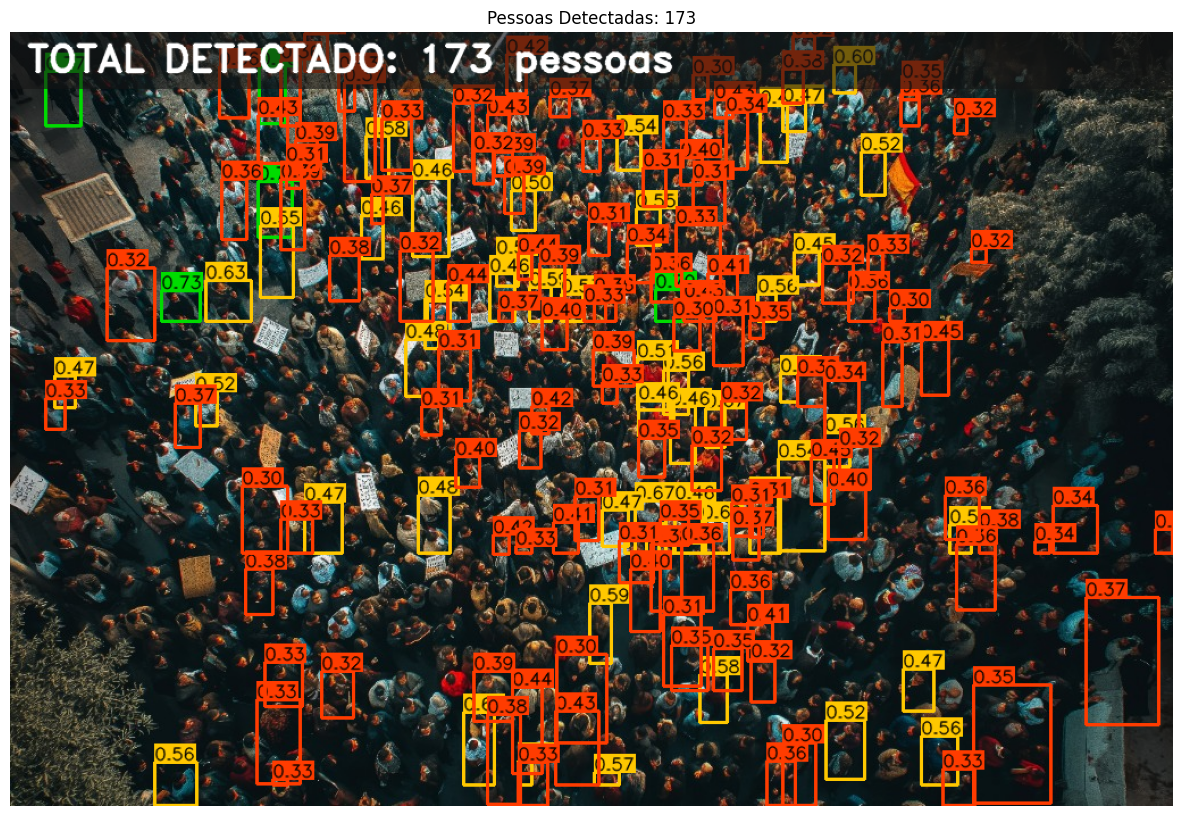

In [18]:
# Mostra a imagem com matplotlib
img_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 15))
plt.imshow(img_rgb)
plt.axis('off')
plt.title(f"Pessoas Detectadas: {count}")
plt.show()

# Opcional: Download automático do resultado
# files.download(OUTPUT_PATH)

## Fase 3: Geração de Relatórios e Analíticos
Nesta etapa, consolidamos os dados em formato de Inteligência, gerando gráficos, CSV e um Relatório Técnico em Markdown.


In [19]:
import csv
def export_to_csv(detections, output_csv='detections.csv'):
    with open(output_csv, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['id', 'x1', 'y1', 'x2', 'y2', 'center_x', 'center_y', 'confidence', 'class'])
        for i, d in enumerate(detections, 1):
            center_x = (d.x1 + d.x2) / 2.0
            center_y = (d.y1 + d.y2) / 2.0
            writer.writerow([
                i, f'{d.x1:.2f}', f'{d.y1:.2f}', f'{d.x2:.2f}', f'{d.y2:.2f}',
                f'{center_x:.2f}', f'{center_y:.2f}', f'{d.confidence:.4f}', d.class_name
            ])
    print(f'[CSV] Exportou {len(detections)} detecções para {output_csv}')


In [20]:
import matplotlib.pyplot as plt
import numpy as np

def generate_confidence_histogram(detections, output_path='conf_histogram.png'):
    confidences = [d.confidence for d in detections]
    plt.figure(figsize=(8, 5))
    plt.hist(confidences, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title('Distribuição da Confiança (YOLOv8)', fontsize=14)
    plt.xlabel('Grau de Confiança', fontsize=12)
    plt.ylabel('Frequência (Quantidade de Pessoas)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    if confidences:
        mean_conf = np.mean(confidences)
        plt.axvline(mean_conf, color='red', linestyle='dashed', linewidth=2, label=f'Média: {mean_conf:.2f}')
        plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.close()
    print(f'[Gráfico] Histograma salvo em {output_path}')

def generate_density_heatmap(mosaic_shape, detections, output_path='density_heatmap.png'):
    h, w = mosaic_shape[:2]
    x_centers = [(d.x1 + d.x2) / 2.0 for d in detections]
    y_centers = [(d.y1 + d.y2) / 2.0 for d in detections]
    plt.figure(figsize=(8, 6))
    plt.hist2d(x_centers, y_centers, bins=[50, 50], range=[[0, w], [0, h]], cmap='magma')
    plt.gca().invert_yaxis()
    plt.title('Mapa de Calor da Densidade de Público', fontsize=14)
    plt.xlabel('Eixo X (Pixels)', fontsize=12)
    plt.ylabel('Eixo Y (Pixels)', fontsize=12)
    plt.colorbar(label='Indivíduos por Célula da Grade')
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.close()
    print(f'[Gráfico] Mapa de calor salvo em {output_path}')


In [21]:
import datetime

def generate_full_report(process_name, expert_name, total_count, img_shape, param_conf, param_iou,
                         report_path='relatorio_tecnico.md', output_img_name='resultado_contagem.jpg',
                         heatmap_img='density_heatmap.png', hist_img='conf_histogram.png', export_csv='detections.csv'):
    h, w = img_shape[:2]
    date_str = datetime.datetime.now().strftime('%d/%m/%Y %H:%M:%S')
    
    content = f"""# Relatório Técnico - Contagem Analítica de Público

**Data de Geração:** {date_str}
**Processo/Evento:** {process_name}
**Analista/Perito:** {expert_name}

---
## 1. Resumo da Operação
A análise foi realizada através de segmentação da imagem (*tiling*) e inferência por inteligência artificial (Modelo YOLOv8).

- **Resolução da Imagem Analisada:** {w}x{h} px
- **Limiares de Qualidade:**
  - Confiança Mínima (*Confidence Threshold*): {param_conf}
  - Supressão Não Máxima (*Global IoU*): {param_iou}

### 🎯 TOTAL DETECTADO: {total_count} indivíduos

---
## 2. Resultado Visual da Detecção
Abaixo encontra-se o mosaico processado com as caixas delimitadoras (*bounding boxes*) desenhadas sobre cada indivíduo detectado.

![Imagem Processada]({output_img_name})

---
## 3. Análise Estatística e Computacional
Os gráficos a seguir comprovam a acurácia do modelo e demonstram a densidade posicional do público na cena mapeada.

### Distribuição de Confiança (Accuracy)
O histograma reflete a certeza matemática do algoritmo em cada detecção.
![Histograma de Confiança]({hist_img})

### Mapa de Calor da Densidade (Heatmap)
O mapa de calor ilustra as regiões com maior concentração de pessoas.
![Mapa de Calor]({heatmap_img})

---
## 4. Conclusão e Dados Brutos
O algoritmo rodou com sucesso sem gerar redundâncias de borda (aplicado Filtro NMS Global).
Os dados brutos com as coordenadas de todos os indivíduos detectados foram salvos e podem ser auditados no arquivo:
📂 `{export_csv}`

*Relatório gerado automaticamente pelo Agente de Contagem de Público.*
"""
    with open(report_path, 'w', encoding='utf-8') as f:
        f.write(content)
    print(f'[Relatório] Relatório técnico gerado em {report_path}')


In [14]:
# Executando toda a Fase 3
export_to_csv(final_detections)
generate_confidence_histogram(final_detections)
generate_density_heatmap(mosaic_rgb.shape, final_detections)
generate_full_report(
    process_name='Inspeção Aérea - Teste Colab',
    expert_name='PeritoGeo AI',
    total_count=count,
    img_shape=mosaic_rgb.shape,
    param_conf=CONF_THRESH,
    param_iou=IOU_GLOBAL
)
print('Fase 3 finalizada com sucesso. Os arquivos foram salvos no ambiente do Colab.')


[CSV] Exportou 173 detecções para detections.csv
[Gráfico] Histograma salvo em conf_histogram.png


NameError: name 'mosaic_rgb' is not defined